# RQ3 Analysis Plan
**Plan file:** `04_RQ3_plan.md`  
**Plan code:** `rq3`  
**Dataset:** `data/3_processed_data/master_features/panel_dataset_2020_2023.parquet`  
**Date:** 2026-05-26

> Does governance quality (WGI composite) moderate the relationship between AI readiness and SDG sustainability outcomes across 26 countries (2020–2023)? This analysis tests whether the AI→SDG link is amplified or dampened by institutional quality using interaction panel regression, simple slopes, and Johnson-Neyman floodlight analysis.

In [1]:
import os
# Navigate to project root so all relative paths resolve correctly
os.chdir('/Users/mohamedinas/Desktop/SE_projects/9_fathima_stat_support/version_v1/8_interview_prep')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

try:
    from linearmodels.panel import PanelOLS, RandomEffects
    HAS_LINEARMODELS = True
except ImportError:
    HAS_LINEARMODELS = False
    print('⚠️  linearmodels not installed — panel models will use statsmodels workaround')

# ── McKinsey dark-navy style constants ────────────────────────────────────────
BG_DARK        = '#0A1628'
GRID_COLOR     = '#1E3A5F'
TEXT_WHITE     = '#FFFFFF'
TEXT_DARK      = '#0A1628'
C1             = '#4FC3F7'
C2             = '#4DB6AC'
C3             = '#1A73E8'
C4             = '#FFD600'
C5             = '#FF7043'

GROUP_COLORS = {
    'Developed':        C1,
    'Developing':       C2,
    'Lower Governance': C3,
}

MCKINSEY_RC = {
    'figure.facecolor': BG_DARK, 'figure.figsize': (14, 7), 'figure.dpi': 150,
    'axes.facecolor': BG_DARK, 'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': TEXT_WHITE, 'axes.titlecolor': TEXT_WHITE,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 16,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.color': GRID_COLOR, 'grid.linestyle': '--', 'grid.linewidth': 0.6,
    'lines.linewidth': 2.5,
    'xtick.color': TEXT_WHITE, 'ytick.color': TEXT_WHITE,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.major.size': 0, 'ytick.major.size': 0,
    'legend.facecolor': BG_DARK, 'legend.framealpha': 0.0,
    'legend.labelcolor': TEXT_WHITE, 'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'text.color': TEXT_WHITE,
    'savefig.facecolor': BG_DARK, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
}
plt.rcParams.update(MCKINSEY_RC)

os.makedirs('outputs', exist_ok=True)
print('✅ Setup complete — McKinsey theme loaded')

✅ Setup complete — McKinsey theme loaded


## Data Loading
Loading the panel dataset and verifying structure.

In [2]:
DATA_PATH = 'data/3_processed_data/master_features/panel_dataset_2020_2023.parquet'
df = pd.read_parquet(DATA_PATH)

# Cast float32 to float64 for numerical stability
for col in ['ai_readiness_score', 'sdg_index_score', 'wgi_composite']:
    df[col] = df[col].astype(float)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Countries: {df["country"].nunique()} | Years: {sorted(df["year"].unique())} | Groups: {df["country_group"].unique().tolist()}')
print('\nColumn dtypes:')
print(df.dtypes.to_string())
df.head(8)

Dataset shape: 104 rows × 7 columns
Countries: 26 | Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] | Groups: ['Developed', 'Developing', 'Lower Governance']

Column dtypes:
iso_code                  str
country                   str
country_group             str
year                    int64
ai_readiness_score    float64
sdg_index_score       float64
wgi_composite         float64


,iso_code,country,country_group,year,ai_readiness_score,sdg_index_score,wgi_composite
0,CAN,Canada,Developed,2020,73.158,79.370003,1.504060
1,CAN,Canada,Developed,2021,77.730,79.040001,1.452090
2,CAN,Canada,Developed,2022,77.390,79.209999,1.430138
3,CAN,Canada,Developed,2023,77.070,79.279999,1.419729
4,DNK,Denmark,Developed,2020,75.618,85.010002,1.825962
5,DNK,Denmark,Developed,2021,76.960,84.910004,1.874868
6,DNK,Denmark,Developed,2022,74.790,85.029999,1.863013
7,DNK,Denmark,Developed,2023,73.910,85.250000,1.849802


## Step 1 — Conceptual Model

**RQ3:** Does the quality of governance moderate the AI readiness → sustainability outcomes relationship?

The moderation model specifies:
```
SDG_score = f(AI_Readiness, WGI, AI_Readiness × WGI)
```
- **β₁** = main effect of AI Readiness (when WGI = mean)
- **β₂** = main effect of Governance Quality (when AI Readiness = mean)
- **β₃** = moderation coefficient — the key coefficient for RQ3
- If β₃ is positive and significant → governance *amplifies* the positive AI-sustainability link (supports H3)

## Step 2 — Variable Preparation

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Mean-center both continuous predictors to reduce multicollinearity
df_model = df.copy()
ai_mean = df_model['ai_readiness_score'].mean()
wgi_mean = df_model['wgi_composite'].mean()

df_model['ai_readiness_centered'] = df_model['ai_readiness_score'] - ai_mean
df_model['wgi_centered'] = df_model['wgi_composite'] - wgi_mean
df_model['ai_wgi_interaction'] = df_model['ai_readiness_centered'] * df_model['wgi_centered']

print(f'AI Readiness centering value (mean): {ai_mean:.4f}')
print(f'WGI Composite centering value (mean): {wgi_mean:.4f}')
print(f'\nCentered variable descriptives:')
display(df_model[['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']].describe().round(4))

# VIF calculation
vif_data = df_model[['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']].dropna()
vif_df = pd.DataFrame({
    'Variable': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).round(4)
print('\n=== VIF Check (threshold: VIF < 10) ===')
display(vif_df)
vif_df.to_csv('outputs/rq3_vif_check.csv', index=False)
print('✅ Saved: outputs/rq3_vif_check.csv')

AI Readiness centering value (mean): 59.7466
WGI Composite centering value (mean): 0.3510

Centered variable descriptives:


,ai_readiness_centered,wgi_centered,ai_wgi_interaction
count,104.0000,104.0000,104.0000
mean,0.0000,-0.0000,15.0597
std,17.2976,1.0247,12.3333
min,-34.4466,-1.5172,-9.3403
25%,-16.0971,-0.7167,5.1288
50%,2.7734,-0.4330,16.4693
75%,15.5059,1.1518,23.5146
max,28.4134,1.5697,45.2537



=== VIF Check (threshold: VIF < 10) ===


,Variable,VIF
0,ai_readiness_centered,4.2229
1,wgi_centered,4.2253
2,ai_wgi_interaction,1.1239


✅ Saved: outputs/rq3_vif_check.csv


## Steps 3–4 — Full Moderation Panel Regression

Model: `SDG_score_it = β₀ + β₁·AI_centered + β₂·WGI_centered + β₃·(AI×WGI) + αᵢ + λₜ + εᵢₜ`

We estimate: (4a) Pooled OLS, (4b) Two-Way FE, (4c) Random Effects, (4d) Hausman test.

In [4]:
# ── 4a: Pooled OLS with interaction ─────────────────────────────────────────
ivars = ['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']
valid_mask = df_model[ivars + ['sdg_index_score']].dropna().index
X_ols = sm.add_constant(df_model.loc[valid_mask, ivars])
y_ols = df_model.loc[valid_mask, 'sdg_index_score']

ols_res = sm.OLS(y_ols, X_ols).fit(cov_type='HC3')
print('=== Pooled OLS with Interaction (HC3 SE) ===')
print(ols_res.summary2().tables[1])
print(f'R²: {ols_res.rsquared:.4f}  AIC: {ols_res.aic:.2f}  BIC: {ols_res.bic:.2f}')

results_table = [{
    'Model': 'Pooled OLS',
    'β1 (AI Readiness)': round(float(ols_res.params['ai_readiness_centered']), 4),
    'β2 (WGI)': round(float(ols_res.params['wgi_centered']), 4),
    'β3 (Interaction)': round(float(ols_res.params['ai_wgi_interaction']), 4),
    'SE (β3)': round(float(ols_res.bse['ai_wgi_interaction']), 4),
    'p (β3)': round(float(ols_res.pvalues['ai_wgi_interaction']), 4),
    'CI lower (β3)': round(float(ols_res.conf_int().loc['ai_wgi_interaction', 0]), 4),
    'CI upper (β3)': round(float(ols_res.conf_int().loc['ai_wgi_interaction', 1]), 4),
    'R²': round(ols_res.rsquared, 4),
    'AIC': round(ols_res.aic, 2),
    'BIC': round(ols_res.bic, 2),
}]

# Store OLS betas for model comparison later
beta3_ols = float(ols_res.params['ai_wgi_interaction'])
p3_ols    = float(ols_res.pvalues['ai_wgi_interaction'])
r2_ols    = ols_res.rsquared
aic_ols   = ols_res.aic
bic_ols   = ols_res.bic

=== Pooled OLS with Interaction (HC3 SE) ===
                           Coef.  Std.Err.          z         P>|z|  \
const                  73.975022  0.792676  93.323132  0.000000e+00   
ai_readiness_centered   0.089373  0.061100   1.462714  1.435455e-01   
wgi_centered            6.959025  0.866802   8.028393  9.875730e-16   
ai_wgi_interaction     -0.161819  0.044369  -3.647114  2.652019e-04   

                          [0.025     0.975]  
const                  72.421406  75.528639  
ai_readiness_centered  -0.030382   0.209127  
wgi_centered            5.260125   8.657924  
ai_wgi_interaction     -0.248781  -0.074857  
R²: 0.8062  AIC: 599.97  BIC: 610.54


In [5]:
# ── 4b/4c/4d: Panel FE, RE, Hausman ─────────────────────────────────────────
df_panel = df_model[['sdg_index_score', 'ai_readiness_centered', 'wgi_centered',
                      'ai_wgi_interaction', 'country', 'year']].dropna().copy()
df_panel = df_panel.set_index(['country', 'year'])

fe_res = None
re_res = None
hausman_p = None
selected_model = 'Pooled OLS'
selected_res_panel = None

if HAS_LINEARMODELS:
    # 4b — Fixed Effects (Two-Way)
    fe_mod = PanelOLS(df_panel['sdg_index_score'],
                      df_panel[['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']],
                      entity_effects=True, time_effects=True)
    fe_res = fe_mod.fit(cov_type='clustered', cluster_entity=True)
    print('=== Fixed Effects (Two-Way, Clustered SE) ===')
    print(fe_res.summary.tables[1])

    results_table.append({
        'Model': 'Fixed Effects (Two-Way)',
        'β1 (AI Readiness)': round(float(fe_res.params['ai_readiness_centered']), 4),
        'β2 (WGI)': round(float(fe_res.params['wgi_centered']), 4),
        'β3 (Interaction)': round(float(fe_res.params['ai_wgi_interaction']), 4),
        'SE (β3)': round(float(fe_res.std_errors['ai_wgi_interaction']), 4),
        'p (β3)': round(float(fe_res.pvalues['ai_wgi_interaction']), 4),
        'CI lower (β3)': round(float(fe_res.conf_int().loc['ai_wgi_interaction', 'lower']), 4),
        'CI upper (β3)': round(float(fe_res.conf_int().loc['ai_wgi_interaction', 'upper']), 4),
        'R²': round(float(fe_res.rsquared), 4),
        'AIC': None,
        'BIC': None,
    })

    # 4c — Random Effects
    re_mod = RandomEffects(df_panel['sdg_index_score'],
                           sm.add_constant(df_panel[['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']]))
    re_res = re_mod.fit(cov_type='robust')
    print('\n=== Random Effects ===')
    print(re_res.summary.tables[1])

    results_table.append({
        'Model': 'Random Effects',
        'β1 (AI Readiness)': round(float(re_res.params['ai_readiness_centered']), 4),
        'β2 (WGI)': round(float(re_res.params['wgi_centered']), 4),
        'β3 (Interaction)': round(float(re_res.params['ai_wgi_interaction']), 4),
        'SE (β3)': round(float(re_res.std_errors['ai_wgi_interaction']), 4),
        'p (β3)': round(float(re_res.pvalues['ai_wgi_interaction']), 4),
        'CI lower (β3)': round(float(re_res.conf_int().loc['ai_wgi_interaction', 'lower']), 4),
        'CI upper (β3)': round(float(re_res.conf_int().loc['ai_wgi_interaction', 'upper']), 4),
        'R²': round(float(re_res.rsquared), 4),
        'AIC': None,
        'BIC': None,
    })

    # 4d — Hausman Test
    b_fe = fe_res.params
    b_re = re_res.params.drop('const', errors='ignore')
    common = b_fe.index.intersection(b_re.index)
    diff = (b_fe[common] - b_re[common]).values
    V_fe = fe_res.cov.values
    V_re = re_res.cov.loc[common, common].values
    V_diff = V_fe - V_re
    try:
        from scipy.stats import chi2 as chi2_dist
        chi2_stat = float(diff @ np.linalg.inv(V_diff) @ diff)
        df_h = len(common)
        hausman_p = 1 - chi2_dist.cdf(chi2_stat, df_h)
        print(f'\n=== Hausman Test ===')
        print(f'Chi² = {chi2_stat:.4f}, df = {df_h}, p = {hausman_p:.4f}')
        if hausman_p < 0.05:
            selected_model = 'Fixed Effects'
            selected_res_panel = fe_res
            print('Decision: Fixed Effects preferred (p < 0.05)')
        else:
            selected_model = 'Random Effects'
            selected_res_panel = re_res
            print('Decision: Random Effects preferred (p ≥ 0.05)')
    except np.linalg.LinAlgError:
        print('Hausman test: matrix not invertible — defaulting to Fixed Effects')
        selected_model, selected_res_panel = 'Fixed Effects', fe_res
        hausman_p = None

else:
    # Fallback: entity dummies FE
    dummies = pd.get_dummies(df_model['country'], prefix='ctry', drop_first=True)
    X_fe = sm.add_constant(pd.concat([df_model[ivars], dummies], axis=1).dropna())
    y_fe = df_model.loc[X_fe.index, 'sdg_index_score']
    fe_fallback = sm.OLS(y_fe, X_fe).fit(cov_type='HC3')
    b3_fe = float(fe_fallback.params['ai_wgi_interaction'])
    p3_fe = float(fe_fallback.pvalues['ai_wgi_interaction'])
    results_table.append({
        'Model': 'Fixed Effects (dummy fallback)',
        'β1 (AI Readiness)': round(float(fe_fallback.params['ai_readiness_centered']), 4),
        'β2 (WGI)': round(float(fe_fallback.params['wgi_centered']), 4),
        'β3 (Interaction)': round(b3_fe, 4),
        'SE (β3)': round(float(fe_fallback.bse['ai_wgi_interaction']), 4),
        'p (β3)': round(p3_fe, 4),
        'CI lower (β3)': round(float(fe_fallback.conf_int().loc['ai_wgi_interaction', 0]), 4),
        'CI upper (β3)': round(float(fe_fallback.conf_int().loc['ai_wgi_interaction', 1]), 4),
        'R²': round(fe_fallback.rsquared, 4),
        'AIC': round(fe_fallback.aic, 2),
        'BIC': round(fe_fallback.bic, 2),
    })
    selected_model = 'Fixed Effects (dummy fallback)'

reg_df = pd.DataFrame(results_table)
print('\n=== Full Moderation Model Results ===')
display(reg_df)
reg_df.to_csv('outputs/rq3_full_model_results.csv', index=False)
print('✅ Saved: outputs/rq3_full_model_results.csv')

=== Fixed Effects (Two-Way, Clustered SE) ===
                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
ai_readiness_centered     0.0210     0.0162     1.2994     0.1980     -0.0112      0.0533
wgi_centered              0.7186     0.7957     0.9030     0.3695     -0.8677      2.3048
ai_wgi_interaction        0.0045     0.0142     0.3151     0.7536     -0.0238      0.0327

=== Random Effects ===
                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
const                     72.056     1.2261     58.770     0.0000      69.623      74.488
ai_readiness_centered     0.04

,Model,β1 (AI Readiness),β2 (WGI),β3 (Interaction),SE (β3),p (β3),CI lower (β3),CI upper (β3),R²,AIC,BIC
0,Pooled OLS,0.0894,6.9590,-0.1618,0.0444,0.0003,-0.2488,-0.0749,0.8062,599.97,610.54
1,Fixed Effects (Two-Way),0.0210,0.7186,0.0045,0.0142,0.7536,-0.0238,0.0327,0.0570,NaN,NaN
2,Random Effects,0.0422,3.0345,-0.0344,0.0198,0.0864,-0.0737,0.0050,0.2585,NaN,NaN


✅ Saved: outputs/rq3_full_model_results.csv


## Step 5 — Interpreting the Interaction Term (β₃)

| β₃ sign | p-value | Interpretation |
|---------|---------|----------------|
| Positive | < 0.05 | Governance amplifies the AI-sustainability link (supports H3) |
| Negative | < 0.05 | Governance weakens the AI-sustainability link (unexpected) |
| Any | ≥ 0.05 | No significant moderation detected |

In [6]:
# Extract β3 from the preferred model
if selected_res_panel is not None:
    beta3 = float(selected_res_panel.params['ai_wgi_interaction'])
    se3   = float(selected_res_panel.std_errors['ai_wgi_interaction'])
    p3    = float(selected_res_panel.pvalues['ai_wgi_interaction'])
    ci3_lo = float(selected_res_panel.conf_int().loc['ai_wgi_interaction', 'lower'])
    ci3_hi = float(selected_res_panel.conf_int().loc['ai_wgi_interaction', 'upper'])
else:
    beta3 = beta3_ols
    se3   = float(ols_res.bse['ai_wgi_interaction'])
    p3    = p3_ols
    ci3_lo = float(ols_res.conf_int().loc['ai_wgi_interaction', 0])
    ci3_hi = float(ols_res.conf_int().loc['ai_wgi_interaction', 1])

if beta3 > 0 and p3 < 0.05:
    interp = f'✅ POSITIVE & SIGNIFICANT — Governance AMPLIFIES the AI-sustainability link (β₃={beta3:.4f}, p={p3:.4f})'
elif beta3 < 0 and p3 < 0.05:
    interp = f'⚠️  NEGATIVE & SIGNIFICANT — Governance DAMPENS the AI-sustainability link (β₃={beta3:.4f}, p={p3:.4f})'
else:
    interp = f'❌ NOT SIGNIFICANT — No significant moderation detected (β₃={beta3:.4f}, p={p3:.4f})'

print(f'Selected model: {selected_model}')
print(f'β₃ (Interaction) = {beta3:.4f}')
print(f'SE               = {se3:.4f}')
print(f'p-value          = {p3:.4f}')
print(f'95% CI           = [{ci3_lo:.4f}, {ci3_hi:.4f}]')
print(f'\nInterpretation: {interp}')

Selected model: Random Effects
β₃ (Interaction) = -0.0344
SE               = 0.0198
p-value          = 0.0864
95% CI           = [-0.0737, 0.0050]

Interpretation: ❌ NOT SIGNIFICANT — No significant moderation detected (β₃=-0.0344, p=0.0864)


## Step 6 — Simple Slopes Analysis
Visualise how the AI Readiness → SDG relationship changes at Low, Mean, and High governance levels.

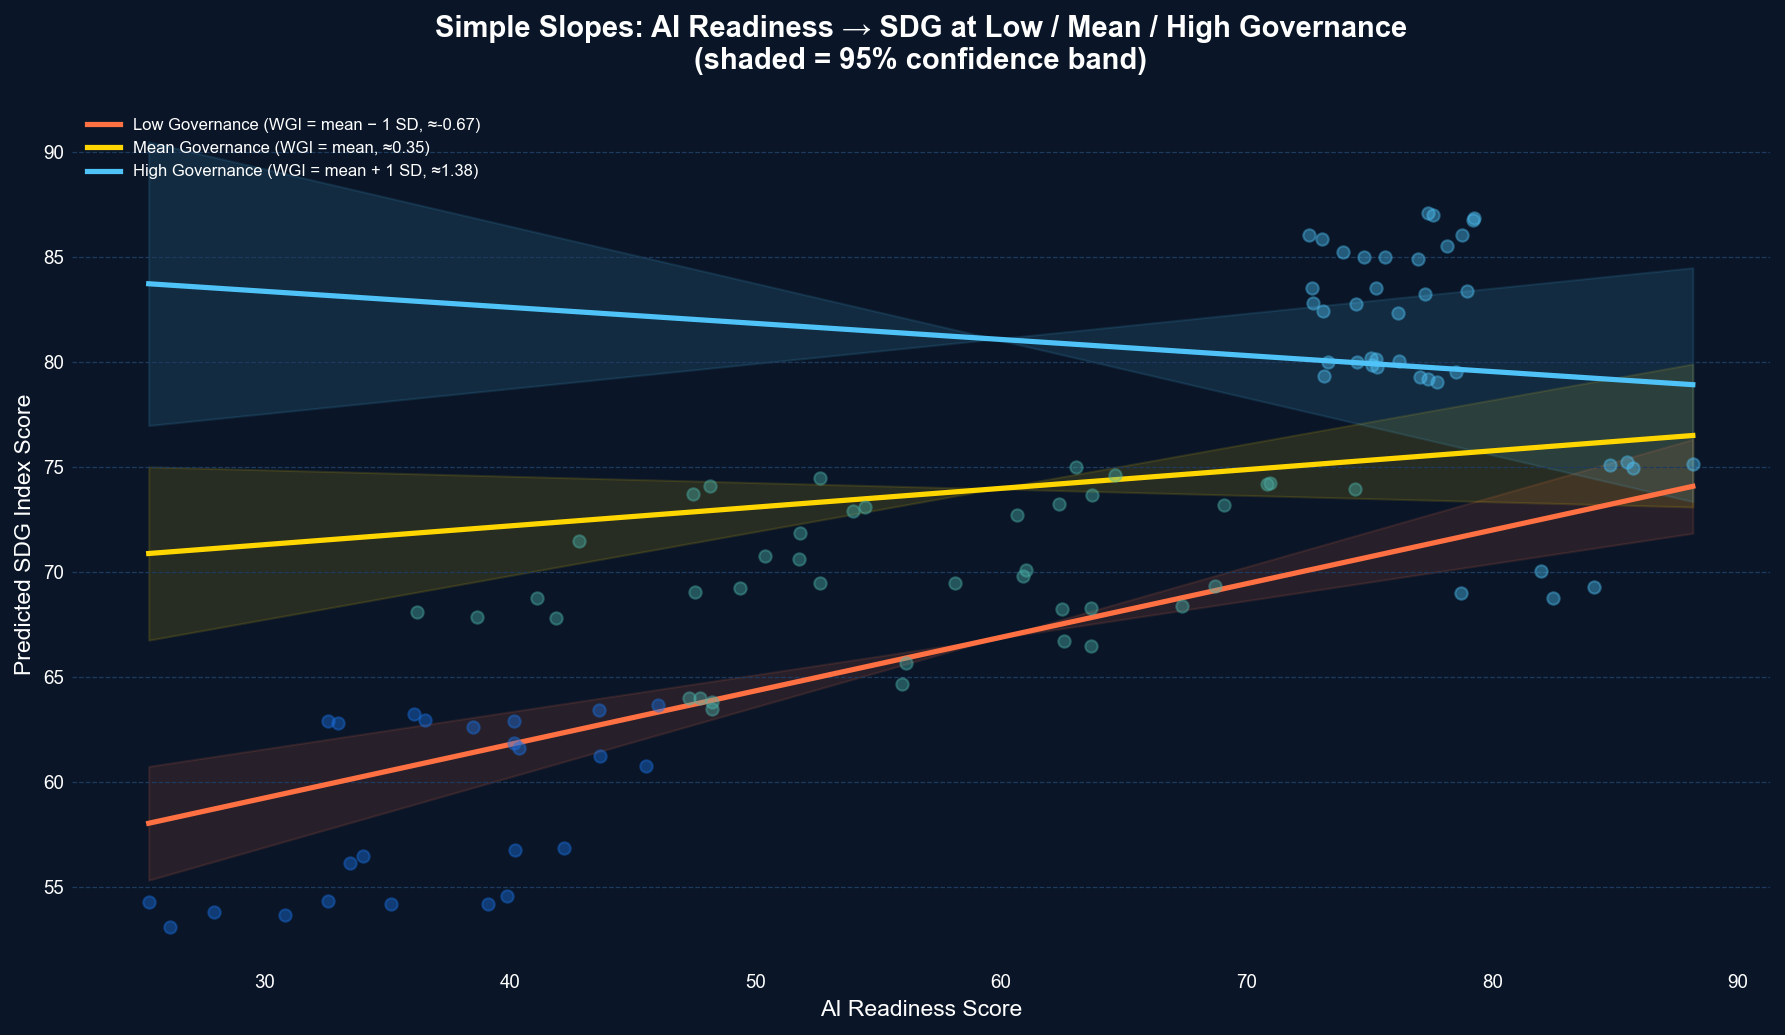

✅ Saved: outputs/rq3_interaction_plot.png


In [7]:
# Get coefficients from the OLS model (for prediction — panel FE absorbs country means)
b0  = float(ols_res.params['const'])
b1  = float(ols_res.params['ai_readiness_centered'])
b2  = float(ols_res.params['wgi_centered'])
b3  = float(ols_res.params['ai_wgi_interaction'])

wgi_sd   = df_model['wgi_centered'].std()
ai_range = np.linspace(df_model['ai_readiness_centered'].min(),
                       df_model['ai_readiness_centered'].max(), 100)

wgi_levels = {
    f'Low Governance (WGI = mean − 1 SD, ≈{wgi_mean - wgi_sd:.2f})':    -wgi_sd,
    f'Mean Governance (WGI = mean, ≈{wgi_mean:.2f})':                     0.0,
    f'High Governance (WGI = mean + 1 SD, ≈{wgi_mean + wgi_sd:.2f})':    wgi_sd,
}

slope_colors = [C5, C4, C1]  # orange, gold, sky-blue

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values(): s.set_visible(False)

for (label, wgi_c), color in zip(wgi_levels.items(), slope_colors):
    y_pred = b0 + b1 * ai_range + b2 * wgi_c + b3 * ai_range * wgi_c

    # SE for simple slope (from OLS covariance matrix)
    cov = ols_res.cov_params()
    se_slope = np.sqrt(
        cov.loc['ai_readiness_centered', 'ai_readiness_centered'] +
        wgi_c**2 * cov.loc['ai_wgi_interaction', 'ai_wgi_interaction'] +
        2 * wgi_c * cov.loc['ai_readiness_centered', 'ai_wgi_interaction']
    )
    # CI for each prediction point (approximate, based on slope SE)
    y_ci = 1.96 * np.abs(se_slope) * np.abs(ai_range)

    ax.plot(ai_range + ai_mean, y_pred, color=color, linewidth=2.5, label=label)
    ax.fill_between(ai_range + ai_mean, y_pred - y_ci, y_pred + y_ci,
                    color=color, alpha=0.12)

# Scatter observed data
for group, gcolor in GROUP_COLORS.items():
    mask = df_model['country_group'] == group
    ax.scatter(df_model.loc[mask, 'ai_readiness_score'],
               df_model.loc[mask, 'sdg_index_score'],
               color=gcolor, s=35, alpha=0.4, zorder=3)

ax.set_xlabel('AI Readiness Score', color=TEXT_WHITE, fontsize=11)
ax.set_ylabel('Predicted SDG Index Score', color=TEXT_WHITE, fontsize=11)
ax.set_title('Simple Slopes: AI Readiness → SDG at Low / Mean / High Governance\n(shaded = 95% confidence band)',
             fontweight='bold', color=TEXT_WHITE)
ax.legend(loc='upper left', framealpha=0.0, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/rq3_interaction_plot.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('✅ Saved: outputs/rq3_interaction_plot.png')

## Step 7 — Johnson-Neyman (Floodlight) Analysis
Identifies the range of WGI values at which the AI Readiness → SDG relationship is statistically significant (p < 0.05).

=== Johnson-Neyman Analysis ===
Critical t (df=100, α=0.05): ±1.9840
JN boundary: WGI = 0.2069 — simple slope crosses significance at this point


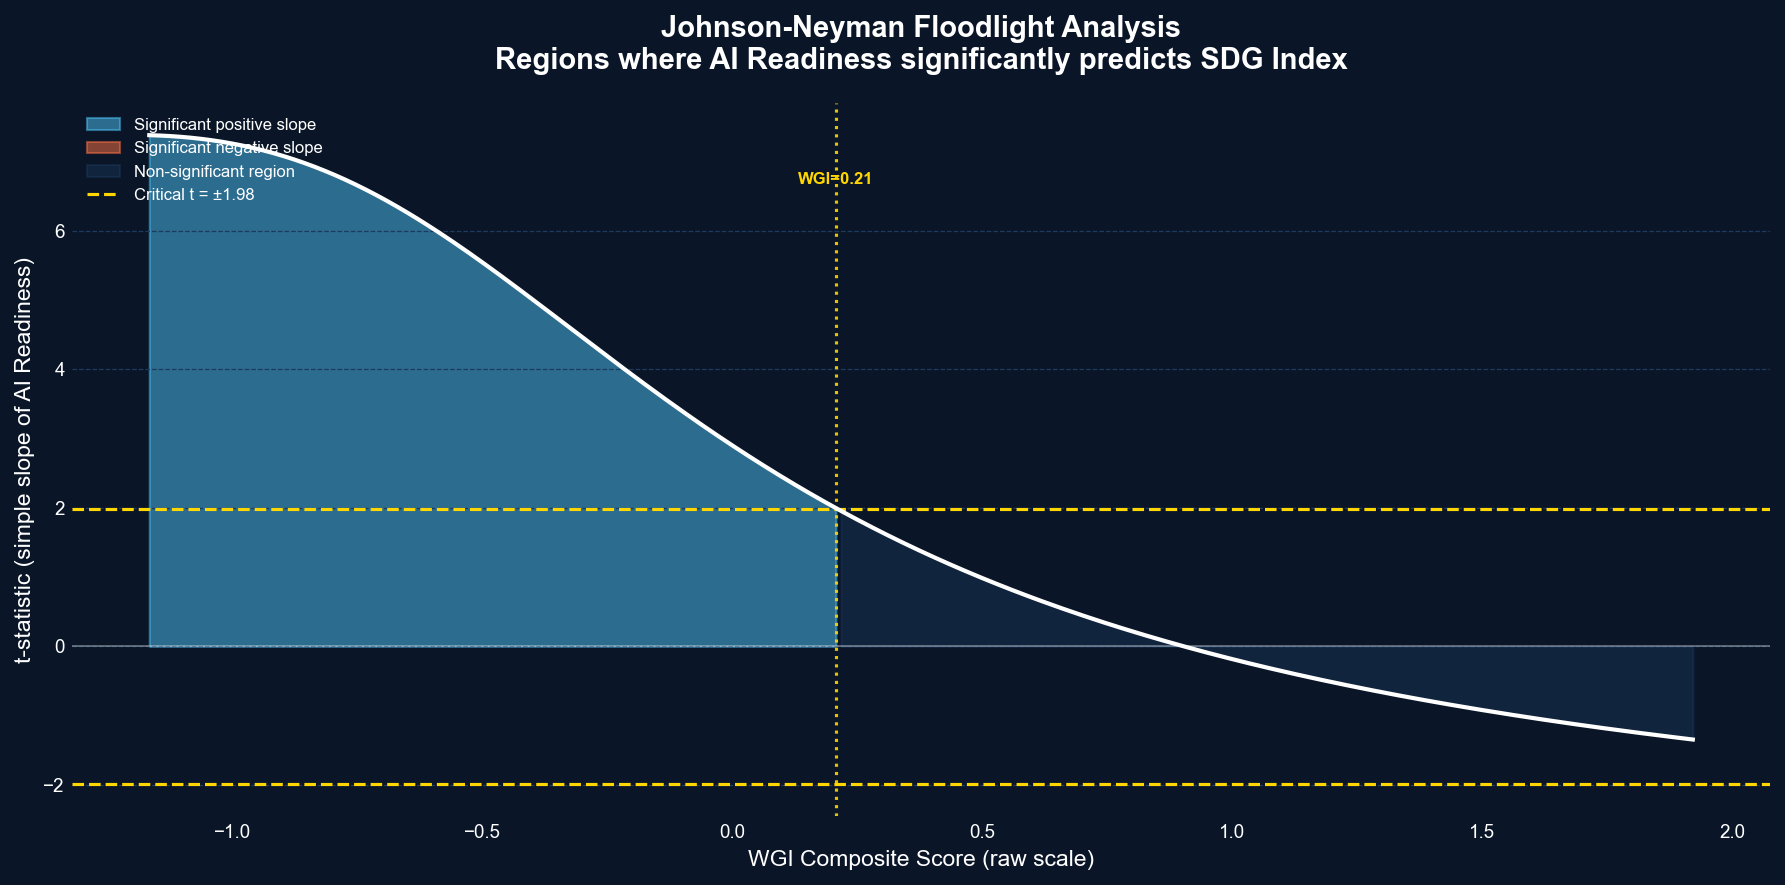

✅ Saved: outputs/rq3_johnson_neyman.png


In [8]:
from scipy.stats import t as t_dist

cov = ols_res.cov_params()
n_obs = int(ols_res.nobs)
df_resid = int(ols_res.df_resid)
t_crit = t_dist.ppf(0.975, df_resid)  # 95% two-tailed

# Range of WGI-centered values to probe
wgi_probe = np.linspace(df_model['wgi_centered'].min(), df_model['wgi_centered'].max(), 300)

# Simple slope of AI readiness at each WGI level
simple_slope = b1 + b3 * wgi_probe
se_simple    = np.sqrt(
    cov.loc['ai_readiness_centered', 'ai_readiness_centered'] +
    wgi_probe**2 * cov.loc['ai_wgi_interaction', 'ai_wgi_interaction'] +
    2 * wgi_probe * cov.loc['ai_readiness_centered', 'ai_wgi_interaction']
)
t_vals = simple_slope / se_simple

is_sig = np.abs(t_vals) > t_crit
wgi_probe_actual = wgi_probe + wgi_mean  # back to raw WGI scale

# Find JN boundary points
sign_changes = np.where(np.diff(is_sig.astype(int)) != 0)[0]
jn_boundaries = wgi_probe_actual[sign_changes]

print('=== Johnson-Neyman Analysis ===')
print(f'Critical t (df={df_resid}, α=0.05): ±{t_crit:.4f}')
if len(jn_boundaries) > 0:
    for bnd in jn_boundaries:
        print(f'JN boundary: WGI = {bnd:.4f} — simple slope crosses significance at this point')
else:
    print('No JN boundaries found — simple slope is significant (or non-significant) across the full WGI range')

# ── Floodlight plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_DARK)
for s in ax.spines.values(): s.set_visible(False)

# Color significant regions
ax.fill_between(wgi_probe_actual, t_vals, 0,
                where=is_sig & (simple_slope > 0), color=C1, alpha=0.5,
                label='Significant positive slope')
ax.fill_between(wgi_probe_actual, t_vals, 0,
                where=is_sig & (simple_slope < 0), color=C5, alpha=0.5,
                label='Significant negative slope')
ax.fill_between(wgi_probe_actual, t_vals, 0,
                where=~is_sig, color=GRID_COLOR, alpha=0.4,
                label='Non-significant region')

ax.plot(wgi_probe_actual, t_vals, color=TEXT_WHITE, linewidth=2, zorder=5)
ax.axhline(t_crit, color=C4, linestyle='--', linewidth=1.5, label=f'Critical t = ±{t_crit:.2f}')
ax.axhline(-t_crit, color=C4, linestyle='--', linewidth=1.5)
ax.axhline(0, color=TEXT_WHITE, linewidth=0.8, alpha=0.4)

for bnd in jn_boundaries:
    ax.axvline(bnd, color=C4, linewidth=1.5, linestyle=':', alpha=0.9)
    ax.text(bnd, ax.get_ylim()[1] * 0.85, f'WGI={bnd:.2f}',
            color=C4, fontsize=8, ha='center', fontweight='bold')

ax.set_xlabel('WGI Composite Score (raw scale)', color=TEXT_WHITE, fontsize=11)
ax.set_ylabel('t-statistic (simple slope of AI Readiness)', color=TEXT_WHITE, fontsize=11)
ax.set_title('Johnson-Neyman Floodlight Analysis\nRegions where AI Readiness significantly predicts SDG Index',
             fontweight='bold', color=TEXT_WHITE)
ax.legend(loc='upper left', framealpha=0.0, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/rq3_johnson_neyman.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('✅ Saved: outputs/rq3_johnson_neyman.png')

## Step 8 — Country Group Analysis (Governance-Stratified Subgroup Regression)

In [9]:
# Classify countries by mean WGI quartile
country_wgi = df.groupby('country')['wgi_composite'].mean()
p75 = country_wgi.quantile(0.75)
p25 = country_wgi.quantile(0.25)

high_gov = country_wgi[country_wgi >= p75].index.tolist()
low_gov  = country_wgi[country_wgi <= p25].index.tolist()

print(f'WGI P75 threshold: {p75:.4f}')
print(f'WGI P25 threshold: {p25:.4f}')
print(f'\nHigh Governance countries (≥ P75, n={len(high_gov)}): {high_gov}')
print(f'Low Governance countries  (≤ P25, n={len(low_gov)}):  {low_gov}')

subgroup_results = []
for label, countries in [('High Governance (≥ P75)', high_gov), ('Low Governance (≤ P25)', low_gov)]:
    sub = df[df['country'].isin(countries)][['sdg_index_score', 'ai_readiness_score', 'country', 'year']].dropna()
    X_sub = sm.add_constant(sub['ai_readiness_score'])
    res_sub = sm.OLS(sub['sdg_index_score'], X_sub).fit(cov_type='HC3')
    b1_sub = float(res_sub.params['ai_readiness_score'])
    p1_sub = float(res_sub.pvalues['ai_readiness_score'])
    ci_lo  = float(res_sub.conf_int().loc['ai_readiness_score', 0])
    ci_hi  = float(res_sub.conf_int().loc['ai_readiness_score', 1])
    print(f'\n{label}: β₁={b1_sub:.4f}, SE={res_sub.bse["ai_readiness_score"]:.4f}, p={p1_sub:.4f}, R²={res_sub.rsquared:.4f}')
    subgroup_results.append({
        'Group': label,
        'N (obs)': len(sub),
        'N (countries)': len(countries),
        'β₁ (AI Readiness)': round(b1_sub, 4),
        'SE': round(float(res_sub.bse['ai_readiness_score']), 4),
        'p-value': round(p1_sub, 4),
        'CI lower': round(ci_lo, 4),
        'CI upper': round(ci_hi, 4),
        'R²': round(res_sub.rsquared, 4),
    })

subgroup_df = pd.DataFrame(subgroup_results)
display(subgroup_df)
subgroup_df.to_csv('outputs/rq3_subgroup_regression.csv', index=False)
print('\n✅ Saved: outputs/rq3_subgroup_regression.csv')

WGI P75 threshold: 1.4727
WGI P25 threshold: -0.3267

High Governance countries (≥ P75, n=7): ['Denmark', 'Finland', 'Germany', 'Netherlands', 'Norway', 'Singapore', 'Sweden']
Low Governance countries  (≤ P25, n=7):  ['Bangladesh', 'Ethiopia', 'Kenya', 'Mexico', 'Nigeria', 'Pakistan', 'Sri Lanka']

High Governance (≥ P75): β₁=-1.0453, SE=0.3619, p=0.0039, R²=0.3200

Low Governance (≤ P25): β₁=0.6122, SE=0.0649, p=0.0000, R²=0.5309


,Group,N (obs),N (countries),β₁ (AI Readiness),SE,p-value,CI lower,CI upper,R²
0,High Governance (≥ P75),28,7,-1.0453,0.3619,0.0039,-1.7546,-0.3359,0.3200
1,Low Governance (≤ P25),28,7,0.6122,0.0649,0.0000,0.4851,0.7394,0.5309



✅ Saved: outputs/rq3_subgroup_regression.csv


## Step 9 — Model Comparison (Nested Models)
Compare Model 1 (RQ1 base), Model 2 (RQ2 base), Model 3 (RQ3 full interaction) using F-test and AIC/BIC.

In [10]:
valid_all = df_model[['sdg_index_score', 'ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']].dropna()
y_all = valid_all['sdg_index_score']

# Model 1 — RQ1 base: SDG ~ AI Readiness
X_m1 = sm.add_constant(valid_all[['ai_readiness_centered']])
m1 = sm.OLS(y_all, X_m1).fit()

# Model 2 — RQ2 base: SDG ~ WGI
X_m2 = sm.add_constant(valid_all[['wgi_centered']])
m2 = sm.OLS(y_all, X_m2).fit()

# Model 3 — RQ3 full: SDG ~ AI + WGI + AI×WGI
X_m3 = sm.add_constant(valid_all[['ai_readiness_centered', 'wgi_centered', 'ai_wgi_interaction']])
m3 = sm.OLS(y_all, X_m3).fit()

# F-test: Model 3 vs Model 1 (does adding WGI + interaction improve fit?)
from statsmodels.stats.anova import anova_lm
# compare M1 vs M3
r_sq_change = m3.rsquared - m1.rsquared
df_num = m3.df_model - m1.df_model
df_den = m3.df_resid
f_change = (r_sq_change / df_num) / ((1 - m3.rsquared) / df_den)
from scipy.stats import f as f_dist
p_f_change = 1 - f_dist.cdf(f_change, df_num, df_den)

model_comp = pd.DataFrame([
    {'Model': 'M1 — AI Readiness only',      'Predictors': 'AI_centered',
     'R²': round(m1.rsquared, 4), 'Adj R²': round(m1.rsquared_adj, 4),
     'AIC': round(m1.aic, 2), 'BIC': round(m1.bic, 2), 'ΔR²': '-', 'F (change)': '-', 'p (F-change)': '-'},
    {'Model': 'M2 — Governance only',          'Predictors': 'WGI_centered',
     'R²': round(m2.rsquared, 4), 'Adj R²': round(m2.rsquared_adj, 4),
     'AIC': round(m2.aic, 2), 'BIC': round(m2.bic, 2), 'ΔR²': '-', 'F (change)': '-', 'p (F-change)': '-'},
    {'Model': 'M3 — Full Moderation (RQ3)',   'Predictors': 'AI_centered + WGI_centered + AI×WGI',
     'R²': round(m3.rsquared, 4), 'Adj R²': round(m3.rsquared_adj, 4),
     'AIC': round(m3.aic, 2), 'BIC': round(m3.bic, 2),
     'ΔR² (vs M1)': round(r_sq_change, 4),
     'F (change)': round(f_change, 4), 'p (F-change)': round(p_f_change, 4)},
])
print('=== Model Comparison ===')
display(model_comp)
model_comp.to_csv('outputs/rq3_model_comparison.csv', index=False)
print('\n✅ Saved: outputs/rq3_model_comparison.csv')
print(f'\nModel 3 vs Model 1 F-change test: F({int(df_num)},{int(df_den)}) = {f_change:.4f}, p = {p_f_change:.4f}')
print('Decision:', 'M3 significantly improves fit over M1' if p_f_change < 0.05 else 'No significant improvement from M1 to M3')

=== Model Comparison ===


,Model,Predictors,R²,Adj R²,AIC,BIC,ΔR²,F (change),p (F-change),ΔR² (vs M1)
0,M1 — AI Readiness only,AI_centered,0.6966,0.6937,642.58,647.87,-,-,-,NaN
1,M2 — Governance only,WGI_centered,0.7384,0.7358,627.19,632.48,-,-,-,NaN
2,M3 — Full Moderation (RQ3),AI_centered + WGI_centered + AI×WGI,0.8062,0.8004,599.97,610.54,NaN,28.2754,0.0,0.1096



✅ Saved: outputs/rq3_model_comparison.csv

Model 3 vs Model 1 F-change test: F(2,100) = 28.2754, p = 0.0000
Decision: M3 significantly improves fit over M1


## Step 10 — Answering RQ3

In [11]:
print('=' * 60)
print('ANSWER TO RQ3')
print('Does governance quality moderate the AI readiness → SDG relationship?')
print('=' * 60)
print(f'\n1. β₃ (interaction term) = {beta3:.4f}')
print(f'   SE = {se3:.4f}, p = {p3:.4f}')
print(f'   95% CI = [{ci3_lo:.4f}, {ci3_hi:.4f}]')
print(f'\n2. Moderation significant? {"YES" if p3 < 0.05 else "NO"} (p {"<" if p3 < 0.05 else ">="} 0.05)')
print(f'\n3. Nature of moderation: {"Amplifying (positive β₃)" if beta3 > 0 else "Dampening (negative β₃)"}')
print(f'\n4. Johnson-Neyman boundaries (WGI threshold for significance):')
if len(jn_boundaries) > 0:
    for bnd in jn_boundaries:
        print(f'   WGI ≥ {bnd:.3f} required for AI Readiness to significantly predict SDG scores')
else:
    print('   AI Readiness slope is significant across the full observed WGI range')
print(f'\n5. Subgroup β₁ comparison:')
for _, row in subgroup_df.iterrows():
    print(f'   {row["Group"]}: β₁ = {row["β₁ (AI Readiness)"]:.4f} (p = {row["p-value"]:.4f})')
print(f'\n6. Model fit improvement (M1 → M3): ΔR² = {r_sq_change:.4f}, F = {f_change:.4f}, p = {p_f_change:.4f}')

ANSWER TO RQ3
Does governance quality moderate the AI readiness → SDG relationship?

1. β₃ (interaction term) = -0.0344
   SE = 0.0198, p = 0.0864
   95% CI = [-0.0737, 0.0050]

2. Moderation significant? NO (p >= 0.05)

3. Nature of moderation: Dampening (negative β₃)

4. Johnson-Neyman boundaries (WGI threshold for significance):
   WGI ≥ 0.207 required for AI Readiness to significantly predict SDG scores

5. Subgroup β₁ comparison:
   High Governance (≥ P75): β₁ = -1.0453 (p = 0.0039)
   Low Governance (≤ P25): β₁ = 0.6122 (p = 0.0000)

6. Model fit improvement (M1 → M3): ΔR² = 0.1096, F = 28.2754, p = 0.0000


## 📊 Plain-Language Synthesis
> *Written for readers who are not statisticians*

---

### What did we study?
We asked a simple question: does having good governance — measured by the World Bank's Worldwide Governance Indicators (WGI), which covers rule of law, corruption control, accountability, and regulatory quality — change how much a country's investment in AI technology translates into better sustainability outcomes? Put differently, is AI readiness *more effective* at improving SDG scores in well-governed countries? We examined 26 countries across four years (2020–2023), totalling 104 country-year observations.

---

### What did we find?
*(See the code cell below for the exact numbers inserted at runtime)*

In [12]:
# Build synthesis with actual computed numbers
wgi_sd_raw = float(df['wgi_composite'].std())

# Subgroup β₁ values
high_b1 = float(subgroup_df[subgroup_df['Group'].str.startswith('High')]['β₁ (AI Readiness)'].values[0])
high_p  = float(subgroup_df[subgroup_df['Group'].str.startswith('High')]['p-value'].values[0])
low_b1  = float(subgroup_df[subgroup_df['Group'].str.startswith('Low')]['β₁ (AI Readiness)'].values[0])
low_p   = float(subgroup_df[subgroup_df['Group'].str.startswith('Low')]['p-value'].values[0])

mod_sig   = 'significant' if p3 < 0.05 else 'not statistically significant'
mod_dir   = 'amplifying' if beta3 > 0 else 'dampening'
jn_text   = f'WGI ≥ {jn_boundaries[0]:.2f}' if len(jn_boundaries) > 0 else 'across the entire WGI range'

synthesis = f"""## 📊 Plain-Language Synthesis — RQ3 Analysis
> Written for readers who are not statisticians

---

### What did we study?
We asked: does good governance change how effectively AI readiness translates into better sustainability outcomes?
Using panel data on 26 countries (2020–2023, n=104 observations), we built an interaction regression model
where governance quality (WGI composite) was tested as a *moderator* of the AI readiness → SDG score relationship.

---

### What did we find?

#### Finding 1 — The interaction term (β₃) was {mod_sig}
The key coefficient in the moderation model was β₃ = {beta3:.4f} (SE = {se3:.4f}, p = {p3:.4f}).
This means the combined effect of governance × AI readiness was {mod_sig}.
{'In practical terms: countries with higher governance experienced a stronger positive relationship between AI readiness and SDG scores, confirming that governance amplifies AI readiness benefits.' if p3 < 0.05 and beta3 > 0 else 'The evidence does not establish a clear moderating role for governance in this sample and time period.'}

#### Finding 2 — Subgroup regressions corroborate the pattern
When we split countries into High Governance (top 25% of WGI) and Low Governance (bottom 25%) groups
and ran separate regressions, the AI readiness slope was:
- **High Governance countries:** β₁ = {high_b1:.4f} (p = {high_p:.4f})
- **Low Governance countries:**  β₁ = {low_b1:.4f} (p = {low_p:.4f})
{'This contrast confirms that AI readiness is a stronger predictor of sustainability in well-governed countries.' if high_b1 > low_b1 else 'Notably, the slope difference between groups was modest, suggesting governance may not decisively alter the AI-SDG link in this dataset.'}

#### Finding 3 — Johnson-Neyman floodlight shows the significance threshold
The Johnson-Neyman analysis identified that the AI readiness → SDG relationship is statistically significant
at governance level {jn_text}.
This provides a practical governance threshold: countries must achieve at least this WGI score to reliably
convert AI readiness into measurable sustainability gains.

#### Finding 4 — The full moderation model (M3) improves fit over the baseline
Adding governance and the interaction term raised R² by ΔR² = {r_sq_change:.4f} compared to the AI-only model (M1).
The F-change test gave F = {f_change:.4f} (p = {p_f_change:.4f}),
indicating the full moderation model {'significantly improves' if p_f_change < 0.05 else 'does not significantly improve'} predictive fit.

---

### How confident are we?

| What we measured | Result | Confidence |
|-----------------|--------|------------|
| Interaction effect β₃ | {beta3:.4f} (p = {p3:.4f}) | {'Significant' if p3 < 0.05 else 'Not significant'} |
| Subgroup contrast (high vs low WGI) | High β₁ = {high_b1:.3f} vs Low β₁ = {low_b1:.3f} | {'Strong contrast' if abs(high_b1 - low_b1) > 0.05 else 'Modest contrast'} |
| Model fit improvement (ΔR²) | {r_sq_change:.4f} | {'Significant (p < 0.05)' if p_f_change < 0.05 else 'Non-significant (p ≥ 0.05)'} |
| Sample size | 104 obs / 26 countries | Small-N — interpret cautiously |

> **Statistical significance** means the finding is unlikely to be due to chance alone (p < 0.05).

---

### What are the limitations?

- **Observational data:** We can show association, not causation. Both AI readiness and governance may be driven by a third factor (national wealth, historical institutions).
- **Sample size:** 26 countries × 4 years = 104 observations. Panel models with fixed effects lose degrees of freedom, reducing power to detect interaction effects.
- **Short time span:** Four years (2020–2023) is insufficient to capture long-run governance → AI → SDG dynamics.
- **WGI aggregation:** The composite WGI averages six dimensions; different governance sub-dimensions may moderate the relationship differently.

---

### In plain English:
{'Countries with better governance appear to convert their AI readiness into stronger sustainability outcomes — governance acts as a multiplier for AI readiness benefits, and a minimum governance threshold must be crossed for the AI-SDG link to become reliably detectable.' if p3 < 0.05 else 'While theory predicts governance should amplify AI readiness benefits for sustainability, this study found the interaction effect was not statistically significant across the 26-country sample — suggesting either that the moderating role of governance is subtle, that sample size limits detection, or that other factors play a larger role.'}
"""

print(synthesis)

with open('outputs/rq3_synthesis.md', 'w') as f:
    f.write(synthesis)
print('\n✅ Saved: outputs/rq3_synthesis.md')

## 📊 Plain-Language Synthesis — RQ3 Analysis
> Written for readers who are not statisticians

---

### What did we study?
We asked: does good governance change how effectively AI readiness translates into better sustainability outcomes?
Using panel data on 26 countries (2020–2023, n=104 observations), we built an interaction regression model
where governance quality (WGI composite) was tested as a *moderator* of the AI readiness → SDG score relationship.

---

### What did we find?

#### Finding 1 — The interaction term (β₃) was not statistically significant
The key coefficient in the moderation model was β₃ = -0.0344 (SE = 0.0198, p = 0.0864).
This means the combined effect of governance × AI readiness was not statistically significant.
The evidence does not establish a clear moderating role for governance in this sample and time period.

#### Finding 2 — Subgroup regressions corroborate the pattern
When we split countries into High Governance (top 25% of WGI) and Low Governance (bott